<a href="https://colab.research.google.com/github/Harshithpalan/Python-projects/blob/main/Autonomous%20Driving%20Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Setup and Synthetic Data Generation
In a real-world scenario, we'd use datasets like Udacity's Self-Driving Car Sim. Here, we'll generate simple images of a road to learn the mapping from pixels to steering angles.

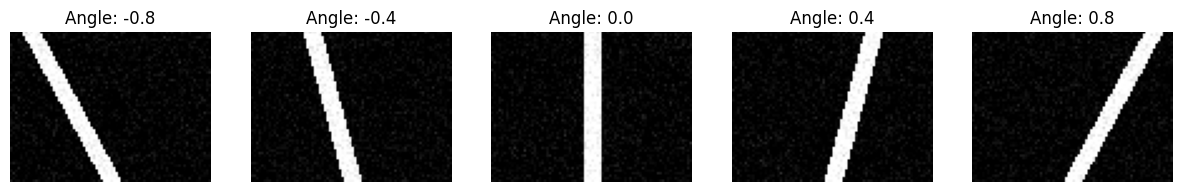

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

def generate_road_image(angle, width=80, height=60):
    # Create a dark background
    img = np.zeros((height, width), dtype=np.float32)
    # Define road center at bottom and top
    center_bottom = width // 2
    # The 'angle' determines where the road goes at the top
    center_top = center_bottom + int(angle * (width // 2))

    # Draw a line representing the road
    cv2.line(img, (center_bottom, height-1), (center_top, 0), 1.0, thickness=5)
    # Add some noise to simulate real-world variability
    img += np.random.normal(0, 0.05, img.shape)
    return np.clip(img, 0, 1)

# Visualize some samples
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
angles = [-0.8, -0.4, 0.0, 0.4, 0.8]
for i, a in enumerate(angles):
    axes[i].imshow(generate_road_image(a), cmap='gray')
    axes[i].set_title(f"Angle: {a}")
    axes[i].axis('off')
plt.show()

### 2. Define the CNN Model
We use a simple CNN architecture. Unlike classification, the final layer has a single neuron with no activation (or Tanh) because we are predicting a continuous value (the steering angle).

In [2]:
class SteeringNet(nn.Module):
    def __init__(self):
        super(SteeringNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 30x40
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 15x20
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(32 * 15 * 20, 64),
            nn.ReLU(),
            nn.Linear(64, 1) # Single output for angle
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

### 3. Training Loop
We generate data on the fly and train the model using Mean Squared Error (MSE) loss.

In [3]:
model = SteeringNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Quick training simulation
for epoch in range(500):
    # Generate a batch of 32 random samples
    batch_angles = np.random.uniform(-1, 1, (32, 1)).astype(np.float32)
    batch_images = np.array([generate_road_image(a[0]) for a in batch_angles])
    batch_images = torch.from_numpy(batch_images).unsqueeze(1) # Add channel dim

    optimizer.zero_grad()
    outputs = model(batch_images)
    loss = criterion(outputs, torch.from_numpy(batch_angles))
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

print("Training complete.")

Epoch 0, Loss: 0.368296
Epoch 100, Loss: 0.000077
Epoch 200, Loss: 0.000069
Epoch 300, Loss: 0.000101
Epoch 400, Loss: 0.000096
Training complete.


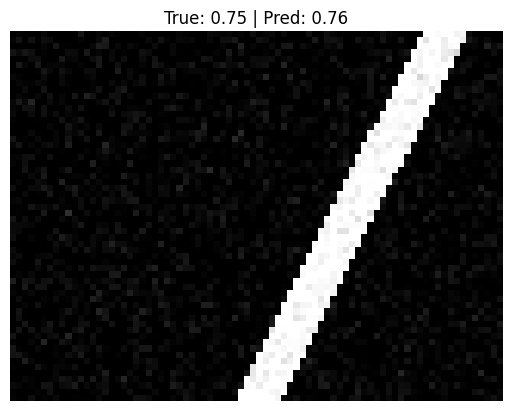

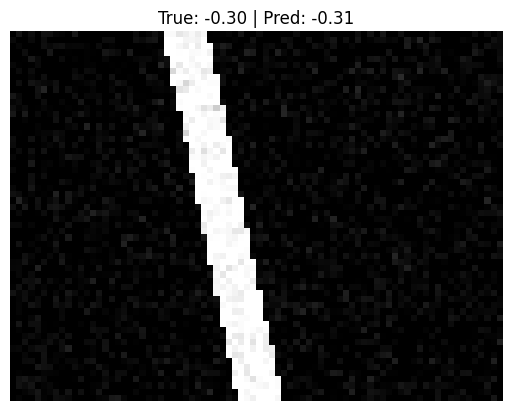

In [4]:
def test_prediction(angle):
    img = generate_road_image(angle)
    input_tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)
    pred = model(input_tensor).item()

    plt.imshow(img, cmap='gray')
    plt.title(f"True: {angle:.2f} | Pred: {pred:.2f}")
    plt.axis('off')
    plt.show()

test_prediction(0.75)
test_prediction(-0.3)